현재 XGBoost 분석은 최종 K-Means 위험군 라벨이 확정되기 전이므로, 코드 구조 확인을 위해 임시 규칙 기반 target을 생성하여 테스트하였다.  
추후 팀원의 최종 K-Means 결과에서 위험군 라벨이 확정되면 해당 라벨을 target으로 교체하여 XGBoost를 재실행할 예정이다.

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# K-menas 결과를 바탕으로 XGboost 실행

In [3]:
BASE_DIR = Path("../data").resolve()
DATA_PATH = BASE_DIR / "for_xgboost_file_0.csv"

df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("data shape:", df.shape)
display(df.head())
display(df["gentrification_risk"].value_counts())

data shape: (50, 14)


,gu,adm_dong_nm,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final,cluster,gentrification_risk
0,수정구,신흥1동,0.053756,0.866667,-0.004179,5.055550,0.041131,0.043389,1.000000,12.246708,1.129590,0.990485,3,0
1,수정구,신흥2동,0.053756,0.866667,-0.000702,6.810407,1.316647,0.405311,0.500000,13.874207,1.135723,1.536592,1,1
2,수정구,신흥3동,0.053756,0.866667,-0.000338,5.920700,-0.193776,0.112441,0.000000,12.972065,0.990797,1.160680,3,0
3,수정구,태평1동,0.046877,0.483871,-0.002679,5.300565,-0.921823,0.618592,1.750000,13.511190,0.925970,0.902802,3,0
4,수정구,태평2동,0.046877,0.483871,-0.001200,4.217316,-0.022637,0.995042,-0.666667,12.784624,1.024391,0.993374,0,0


gentrification_risk
0    34
1    16
Name: count, dtype: int64

In [4]:
feature_cols = [
    "land_price_growth_final",
    "transaction_growth_final",
    "mkt_vital_balance",
    "franchise_ratio_recent4_mean",
    "franchise_ratio_change",
    "bus_total_growth",
    "new_corp_growth",
    "external_inflow_log_recent",
    "close_rate_recent_final",
    "open_rate_recent_final",
]

target_col = "gentrification_risk"

X = df[feature_cols].copy()
X = X.fillna(X.median())
y = df[target_col].copy()

print("X:", X.shape)
print("y 분포:")
display(y.value_counts())
display(X.isna().sum())

X: (50, 10)
y 분포:


gentrification_risk
0    34
1    16
Name: count, dtype: int64

land_price_growth_final         0
transaction_growth_final        0
mkt_vital_balance               0
franchise_ratio_recent4_mean    0
franchise_ratio_change          0
bus_total_growth                0
new_corp_growth                 0
external_inflow_log_recent      0
close_rate_recent_final         0
open_rate_recent_final          0
dtype: int64

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y,
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("train y 분포:")
display(y_train.value_counts())

print("test y 분포:")
display(y_test.value_counts())

print("scale_pos_weight:", scale_pos_weight)

train y 분포:


gentrification_risk
0    24
1    11
Name: count, dtype: int64

test y 분포:


gentrification_risk
0    10
1     5
Name: count, dtype: int64

scale_pos_weight: 2.1818181818181817


In [6]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    scale_pos_weight=scale_pos_weight,
)

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=["실제 0", "실제 1"],
    columns=["예측 0", "예측 1"],
))

print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.8


,예측 0,예측 1
실제 0,10,0
실제 1,3,2


              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.40      0.57         5

    accuracy                           0.80        15
   macro avg       0.88      0.70      0.72        15
weighted avg       0.85      0.80      0.77        15



|      | 예측 0 | 예측 1 |
| ---- | ---: | ---: |
| 실제 0 |   10 |    0 |
| 실제 1 |    3 |    2 |


In [7]:
test_proba = xgb_model.predict_proba(X_test)[:, 1]

for threshold in [0.3, 0.4, 0.5, 0.6]:
    pred_t = (test_proba >= threshold).astype(int)

    print("=" * 50)
    print("threshold:", threshold)
    print(confusion_matrix(y_test, pred_t))
    print(classification_report(y_test, pred_t, zero_division=0))

threshold: 0.3
[[10  0]
 [ 1  4]]
              precision    recall  f1-score   support

           0       0.91      1.00      0.95        10
           1       1.00      0.80      0.89         5

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15

threshold: 0.4
[[10  0]
 [ 2  3]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.60      0.75         5

    accuracy                           0.87        15
   macro avg       0.92      0.80      0.83        15
weighted avg       0.89      0.87      0.86        15

threshold: 0.5
[[10  0]
 [ 3  2]]
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.40      0.57         5

    accuracy                           0.80        15
   macro avg       0.88   

In [8]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb_model.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(importance_df)

,feature,importance
0,open_rate_recent_final,0.219153
1,new_corp_growth,0.177580
2,land_price_growth_final,0.103908
3,external_inflow_log_recent,0.088021
4,franchise_ratio_change,0.087950
5,bus_total_growth,0.072460
6,close_rate_recent_final,0.068017
7,mkt_vital_balance,0.065583
8,franchise_ratio_recent4_mean,0.060163
9,transaction_growth_final,0.057165


In [9]:
for risk in sorted(df[target_col].unique()):
    temp = df[df[target_col] == risk]
    print(f"\n[gentrification_risk = {risk}] 행정동 수: {len(temp)}")
    print(", ".join(temp["adm_dong_nm"].tolist()))


[gentrification_risk = 0] 행정동 수: 34
신흥1동, 신흥3동, 태평1동, 태평2동, 태평3동, 태평4동, 수진1동, 수진2동, 단대동, 양지동, 복정동, 신촌동, 은행1동, 은행2동, 상대원1동, 상대원2동, 상대원3동, 하대원동, 도촌동, 분당동, 수내2동, 수내3동, 정자동, 정자2동, 정자3동, 서현2동, 이매1동, 이매2동, 야탑2동, 야탑3동, 삼평동, 금곡동, 구미1동, 구미동

[gentrification_risk = 1] 행정동 수: 16
신흥2동, 산성동, 위례동, 고등동, 시흥동, 성남동, 중앙동, 금광1동, 금광2동, 수내1동, 정자1동, 서현1동, 야탑1동, 판교동, 백현동, 운중동


In [10]:
cluster_risk_table = pd.crosstab(df["cluster"], df[target_col])
display(cluster_risk_table)

gentrification_risk,0,1
cluster,,
0,15,0
1,0,6
2,0,10
3,19,0


In [11]:
risk_profile = df.groupby(target_col)[feature_cols].mean().round(4)
display(risk_profile)

,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
gentrification_risk,,,,,,,,,,
0,0.0542,0.9214,0.0002,5.1121,-0.2314,1.2039,0.0303,13.1939,0.9501,1.0160
1,0.0599,0.5083,0.0016,7.8185,0.0093,0.3951,-0.0697,14.0287,0.9971,1.4192


In [12]:
risk_threshold = 0.3

cluster_name_map = {
    0: "종합 성장형",
    1: "상업 급변형",
    2: "인구-과밀 불안정형",
    3: "활력 정체형",
}

df["xgb_risk_proba"] = xgb_model.predict_proba(X)[:, 1]
df["risk_score"] = (df["xgb_risk_proba"] * 100).round(2)
df["risk_score_display"] = df["risk_score"].map(lambda x: f"{x:.2f}")
df["xgb_pred_risk"] = (df["xgb_risk_proba"] >= risk_threshold).astype(int)
df["risk_type"] = df["cluster"].map(cluster_name_map)

df["risk_grade"] = pd.cut(
    df["risk_score"],
    bins=[-1, 30, 50, 70, 100],
    labels=["관찰", "주의", "경계", "관리대상"],
    include_lowest=True,
)

df["risk_range"] = pd.cut(
    df["risk_score"],
    bins=[-1, 30, 50, 70, 100],
    labels=["0~30점", "31~50점", "51~70점", "71~100점"],
    include_lowest=True,
)

risk_base_cols = [
    "gu",
    "adm_dong_nm",
    "cluster",
    "risk_type",
    "gentrification_risk",
    "xgb_pred_risk",
    "xgb_risk_proba",
    "risk_score",
    "risk_score_display",
    "risk_range",
    "risk_grade",
]

risk_result = df[risk_base_cols + feature_cols].sort_values(
    "risk_score",
    ascending=False,
).reset_index(drop=True)

display(risk_result.head(20))

,gu,adm_dong_nm,cluster,risk_type,gentrification_risk,xgb_pred_risk,xgb_risk_proba,risk_score,risk_score_display,risk_range,risk_grade,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
0,수정구,신흥2동,1,상업 급변형,1,1,0.969124,96.910004,96.91,71~100점,관리대상,0.053756,0.866667,-0.000702,6.810407,1.316647,0.405311,0.500000,13.874207,1.135723,1.536592
1,수정구,시흥동,1,상업 급변형,1,1,0.968570,96.860001,96.86,71~100점,관리대상,0.084274,2.494737,0.001209,8.404967,0.781264,0.530987,0.071429,14.359674,1.176893,1.797497
2,수정구,고등동,2,인구-과밀 불안정형,1,1,0.961196,96.120003,96.12,71~100점,관리대상,0.037048,-0.568627,0.004785,6.672292,-1.876183,0.601320,-0.028571,13.682920,0.999448,1.677890
3,분당구,운중동,2,인구-과밀 불안정형,1,1,0.949874,94.989998,94.99,71~100점,관리대상,0.063505,0.640351,0.001421,6.512738,-0.630418,0.468167,0.560976,14.418879,0.983563,1.481750
4,분당구,정자1동,1,상업 급변형,1,1,0.941507,94.150002,94.15,71~100점,관리대상,0.058011,0.094017,0.003998,9.805160,3.901440,0.405451,-0.147059,14.771071,0.808847,1.265834
5,수정구,위례동,2,인구-과밀 불안정형,1,1,0.936960,93.699997,93.70,71~100점,관리대상,0.071874,0.604790,0.003411,6.480637,-1.986967,NaN,-0.235955,14.951489,1.375820,1.729754
6,중원구,금광1동,2,인구-과밀 불안정형,1,1,0.924831,92.480003,92.48,71~100점,관리대상,0.032750,0.277778,0.001384,6.075593,-0.341552,0.660754,-0.888889,13.303834,1.276019,1.736118
7,중원구,금광2동,2,인구-과밀 불안정형,1,1,0.923610,92.360001,92.36,71~100점,관리대상,0.032750,0.277778,-0.001018,5.315923,-0.633704,0.037411,0.000000,13.716617,1.164816,1.382007
8,중원구,중앙동,1,상업 급변형,1,1,0.915485,91.550003,91.55,71~100점,관리대상,0.054080,0.846154,0.001448,5.183398,1.733236,0.450511,-0.714286,12.925626,1.077976,1.361014
9,중원구,성남동,2,인구-과밀 불안정형,1,1,0.885464,88.550003,88.55,71~100점,관리대상,0.040146,-0.209091,0.003810,4.014527,-0.507897,0.244803,0.018182,14.475511,1.258072,1.511633


### 클러스터 별 명칭 해석(평균값을 보고 판단했습니다.)
- (1): 지가 상승(land_price)과 프랜차이즈 비율(franchise_ratio)이 동시에 높은 점을 보아 위험형으로 판단
- (2): 유입 인구(external_inflow)는 많지만 공실률(mkt_vital_balance)과 폐업률이 높은 모순적인 상황으로 나와서 표현했다
- (0): 모든 지표(사업체 수, 거래량 등)가 고르게 상승하고 공실은 적은 긍정적인 상태로 나타났다
- (3): 모든 지표가 낮고 특히 유입 인구가 적은 것을 나타내서 정했다

In [13]:
risk_summary = (
    risk_result.groupby(["cluster", "risk_type", "risk_grade"], observed=True)
    .size()
    .reset_index(name="dong_count")
    .sort_values(["cluster", "risk_grade"])
)

display(risk_summary)

,cluster,risk_type,risk_grade,dong_count
0,0,종합 성장형,관찰,15
1,1,상업 급변형,주의,1
2,1,상업 급변형,관리대상,5
3,2,인구-과밀 불안정형,관찰,1
4,2,인구-과밀 불안정형,주의,1
5,2,인구-과밀 불안정형,관리대상,8
6,3,활력 정체형,관찰,19


In [14]:
import shap

,feature,mean_abs_shap
0,open_rate_recent_final,1.729888
1,franchise_ratio_recent4_mean,0.414984
2,franchise_ratio_change,0.334308
3,external_inflow_log_recent,0.267839
4,transaction_growth_final,0.185218
5,bus_total_growth,0.162795
6,close_rate_recent_final,0.093904
7,mkt_vital_balance,0.086524
8,land_price_growth_final,0.065719
9,new_corp_growth,0.031187


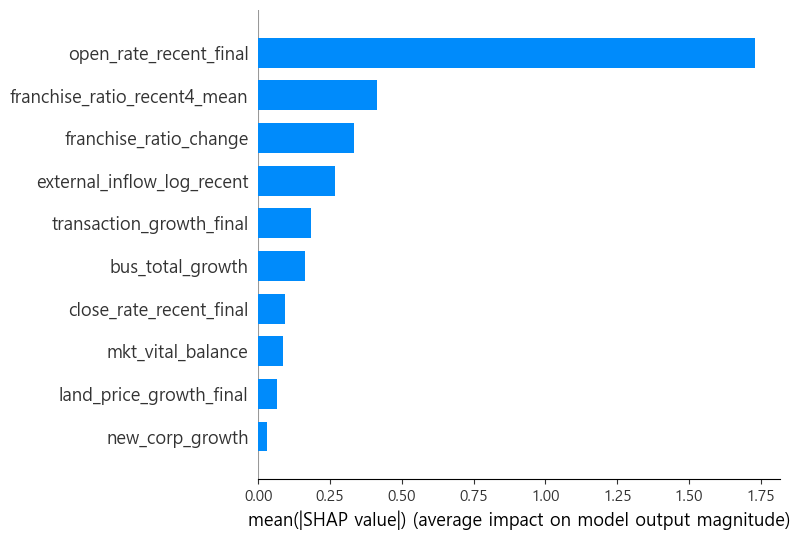

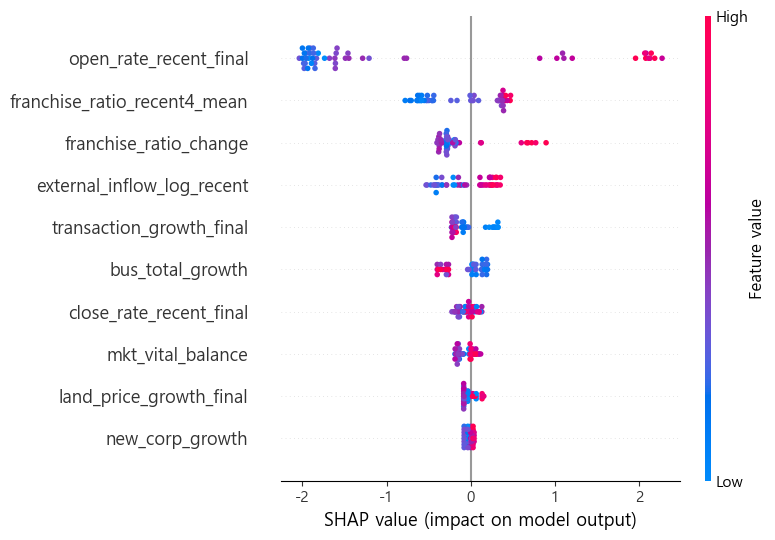

In [15]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

shap_importance = pd.DataFrame({
    "feature": feature_cols,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

display(shap_importance)

shap.summary_plot(shap_values, X, plot_type="bar")
shap.summary_plot(shap_values, X)

전체 50개 행정동 중 위험군은 16개, 비위험군은 34개로 나타났다. 
데이터 수가 많지 않기 때문에 모델 성능 자체보다는 SHAP 기반 변수 해석과 행정동별 위험도 점수 산출에 초점을 두었다.

위험군은 단순 매출 증가보다, 개업률 증가와 프랜차이즈 집중도, 외부유입 규모, 교통 유입 변화가 함께 나타나는 지역으로 해석

SHAP 분석 결과, 위험군 구분에 가장 크게 기여한 변수는 최근 개업률이었다. 이는 위험군으로 정의한 상업 급변형 및 인구-과밀 불안정형 군집에서 신규 점포 진입이 활발하게 나타났기 때문으로 해석된다.
그다음으로 프랜차이즈 최근 비율과 프랜차이즈 변화율이 중요하게 나타나, 브랜드 상권화 및 상권 구조 변화가 위험군 구분에 영향을 준 것으로 볼 수 있다.
또한 외부유입 규모, 부동산 거래 증가율, 버스 승하차 증가율도 위험군 구분에 기여하여, 유입 인구와 교통 접근성 변화가 상권 변화와 함께 나타나는 보조 신호로 해석된다.

In [16]:
shap_df = pd.DataFrame(
    shap_values,
    columns=feature_cols,
    index=X.index,
)

feature_name_map = {
    "land_price_growth_final": "공시지가 상승률",
    "transaction_growth_final": "부동산 거래량 증가율",
    "mkt_vital_balance": "상권 활력 균형",
    "franchise_ratio_recent4_mean": "최근 프랜차이즈 비율",
    "franchise_ratio_change": "프랜차이즈 변화율",
    "bus_total_growth": "버스 승하차 증가율",
    "new_corp_growth": "신규기업 증가율",
    "external_inflow_log_recent": "최근 외부유입 규모",
    "close_rate_recent_final": "최근 폐업률",
    "open_rate_recent_final": "최근 개업률",
}

def get_top_positive_reasons(shap_row, value_row, top_n=3):
    positive = shap_row[shap_row > 0].sort_values(ascending=False)

    if len(positive) == 0:
        positive = shap_row.abs().sort_values(ascending=False)

    result = {}

    for i, feat in enumerate(positive.index[:top_n], start=1):
        result[f"main_reason_{i}"] = feature_name_map.get(feat, feat)
        result[f"main_reason_{i}_col"] = feat
        result[f"main_reason_{i}_value"] = round(value_row[feat], 4)
        result[f"main_reason_{i}_shap"] = round(float(shap_row[feat]), 4)

    return pd.Series(result)

existing_reason_cols = [col for col in df.columns if col.startswith("main_reason_")]
df = df.drop(columns=existing_reason_cols, errors="ignore")

reason_df = pd.DataFrame(
    [
        get_top_positive_reasons(shap_df.loc[idx], X.loc[idx], top_n=3)
        for idx in X.index
    ],
    index=X.index,
)

df = pd.concat([df, reason_df], axis=1)

display(df[
    [
        "gu",
        "adm_dong_nm",
        "risk_score",
        "risk_grade",
        "main_reason_1",
        "main_reason_2",
        "main_reason_3",
    ]
].sort_values("risk_score", ascending=False).head(20))

,gu,adm_dong_nm,risk_score,risk_grade,main_reason_1,main_reason_2,main_reason_3
1,수정구,신흥2동,96.910004,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율
16,수정구,시흥동,96.860001,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율
15,수정구,고등동,96.120003,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모
49,분당구,운중동,94.989998,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모
33,분당구,정자1동,94.150002,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율
13,수정구,위례동,93.699997,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모
19,중원구,금광1동,92.480003,관리대상,최근 개업률,최근 프랜차이즈 비율,상권 활력 균형
20,중원구,금광2동,92.360001,관리대상,최근 개업률,최근 외부유입 규모,최근 폐업률
18,중원구,중앙동,91.550003,관리대상,최근 개업률,프랜차이즈 변화율,버스 승하차 증가율
17,중원구,성남동,88.550003,관리대상,최근 개업률,최근 외부유입 규모,부동산 거래량 증가율


In [17]:
reason_text_cols = [
    "main_reason_1",
    "main_reason_2",
    "main_reason_3",
]
reason_value_cols = [
    "main_reason_1_value",
    "main_reason_2_value",
    "main_reason_3_value",
]
reason_shap_cols = [
    "main_reason_1_shap",
    "main_reason_2_shap",
    "main_reason_3_shap",
]
reason_cols = reason_text_cols + reason_value_cols + reason_shap_cols

for col in reason_text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("해당 없음")

for col in reason_value_cols + reason_shap_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [18]:
risk_result = df[risk_base_cols + reason_cols + feature_cols].sort_values(
    "risk_score",
    ascending=False,
).reset_index(drop=True)

display(risk_result.head(20))

,gu,adm_dong_nm,cluster,risk_type,gentrification_risk,xgb_pred_risk,xgb_risk_proba,risk_score,risk_score_display,risk_range,risk_grade,main_reason_1,main_reason_2,main_reason_3,main_reason_1_value,main_reason_2_value,main_reason_3_value,main_reason_1_shap,main_reason_2_shap,main_reason_3_shap,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
0,수정구,신흥2동,1,상업 급변형,1,1,0.969124,96.910004,96.91,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.5366,1.3166,6.8104,2.0675,0.6651,0.3899,0.053756,0.866667,-0.000702,6.810407,1.316647,0.405311,0.500000,13.874207,1.135723,1.536592
1,수정구,시흥동,1,상업 급변형,1,1,0.968570,96.860001,96.86,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.7975,0.7813,8.4050,1.9585,0.6005,0.4080,0.084274,2.494737,0.001209,8.404967,0.781264,0.530987,0.071429,14.359674,1.176893,1.797497
2,수정구,고등동,2,인구-과밀 불안정형,1,1,0.961196,96.120003,96.12,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모,1.6779,6.6723,13.6829,2.1446,0.3771,0.2232,0.037048,-0.568627,0.004785,6.672292,-1.876183,0.601320,-0.028571,13.682920,0.999448,1.677890
3,분당구,운중동,2,인구-과밀 불안정형,1,1,0.949874,94.989998,94.99,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모,1.4817,6.5127,14.4189,2.1294,0.3846,0.3171,0.063505,0.640351,0.001421,6.512738,-0.630418,0.468167,0.560976,14.418879,0.983563,1.481750
4,분당구,정자1동,1,상업 급변형,1,1,0.941507,94.150002,94.15,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.2658,3.9014,9.8052,1.1067,0.7242,0.4736,0.058011,0.094017,0.003998,9.805160,3.901440,0.405451,-0.147059,14.771071,0.808847,1.265834
5,수정구,위례동,2,인구-과밀 불안정형,1,1,0.936960,93.699997,93.70,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모,1.7298,6.4806,14.9515,2.0794,0.3662,0.3079,0.071874,0.604790,0.003411,6.480637,-1.986967,NaN,-0.235955,14.951489,1.375820,1.729754
6,중원구,금광1동,2,인구-과밀 불안정형,1,1,0.924831,92.480003,92.48,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,상권 활력 균형,1.7361,6.0756,0.0014,2.1861,0.3652,0.1183,0.032750,0.277778,0.001384,6.075593,-0.341552,0.660754,-0.888889,13.303834,1.276019,1.736118
7,중원구,금광2동,2,인구-과밀 불안정형,1,1,0.923610,92.360001,92.36,71~100점,관리대상,최근 개업률,최근 외부유입 규모,최근 폐업률,1.3820,13.7166,1.1648,2.2737,0.2223,0.1043,0.032750,0.277778,-0.001018,5.315923,-0.633704,0.037411,0.000000,13.716617,1.164816,1.382007
8,중원구,중앙동,1,상업 급변형,1,1,0.915485,91.550003,91.55,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,버스 승하차 증가율,1.3610,1.7332,0.4505,2.0834,0.6807,0.1721,0.054080,0.846154,0.001448,5.183398,1.733236,0.450511,-0.714286,12.925626,1.077976,1.361014
9,중원구,성남동,2,인구-과밀 불안정형,1,1,0.885464,88.550003,88.55,71~100점,관리대상,최근 개업률,최근 외부유입 규모,부동산 거래량 증가율,1.5116,14.4755,-0.2091,2.1141,0.3133,0.1762,0.040146,-0.209091,0.003810,4.014527,-0.507897,0.244803,0.018182,14.475511,1.258072,1.511633


In [19]:
df["risk_score"] = df["risk_score"].round(2)
df["risk_score_display"] = df["risk_score"].map(lambda x: f"{x:.2f}")

risk_result["risk_score"] = risk_result["risk_score"].round(2)
risk_result["risk_score_display"] = risk_result["risk_score"].map(lambda x: f"{x:.2f}")

In [20]:
display(risk_result[
    [
        "gu",
        "adm_dong_nm",
        "risk_score_display",
        "risk_grade",
        "main_reason_1",
        "main_reason_2",
        "main_reason_3",
    ]
].head(20))

,gu,adm_dong_nm,risk_score_display,risk_grade,main_reason_1,main_reason_2,main_reason_3
0,수정구,신흥2동,96.91,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율
1,수정구,시흥동,96.86,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율
2,수정구,고등동,96.12,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모
3,분당구,운중동,94.99,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모
4,분당구,정자1동,94.15,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율
5,수정구,위례동,93.70,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모
6,중원구,금광1동,92.48,관리대상,최근 개업률,최근 프랜차이즈 비율,상권 활력 균형
7,중원구,금광2동,92.36,관리대상,최근 개업률,최근 외부유입 규모,최근 폐업률
8,중원구,중앙동,91.55,관리대상,최근 개업률,프랜차이즈 변화율,버스 승하차 증가율
9,중원구,성남동,88.55,관리대상,최근 개업률,최근 외부유입 규모,부동산 거래량 증가율


In [21]:
display(risk_result[
    [
        "gu",
        "adm_dong_nm",
        "risk_score",
        "risk_grade",
        "main_reason_1",
        "main_reason_1_value",
        "main_reason_1_shap",
        "main_reason_2",
        "main_reason_2_value",
        "main_reason_2_shap",
        "main_reason_3",
        "main_reason_3_value",
        "main_reason_3_shap",
    ]
].head(20))

,gu,adm_dong_nm,risk_score,risk_grade,main_reason_1,main_reason_1_value,main_reason_1_shap,main_reason_2,main_reason_2_value,main_reason_2_shap,main_reason_3,main_reason_3_value,main_reason_3_shap
0,수정구,신흥2동,96.910004,관리대상,최근 개업률,1.5366,2.0675,프랜차이즈 변화율,1.3166,0.6651,최근 프랜차이즈 비율,6.8104,0.3899
1,수정구,시흥동,96.860001,관리대상,최근 개업률,1.7975,1.9585,프랜차이즈 변화율,0.7813,0.6005,최근 프랜차이즈 비율,8.4050,0.4080
2,수정구,고등동,96.120003,관리대상,최근 개업률,1.6779,2.1446,최근 프랜차이즈 비율,6.6723,0.3771,최근 외부유입 규모,13.6829,0.2232
3,분당구,운중동,94.989998,관리대상,최근 개업률,1.4817,2.1294,최근 프랜차이즈 비율,6.5127,0.3846,최근 외부유입 규모,14.4189,0.3171
4,분당구,정자1동,94.150002,관리대상,최근 개업률,1.2658,1.1067,프랜차이즈 변화율,3.9014,0.7242,최근 프랜차이즈 비율,9.8052,0.4736
5,수정구,위례동,93.699997,관리대상,최근 개업률,1.7298,2.0794,최근 프랜차이즈 비율,6.4806,0.3662,최근 외부유입 규모,14.9515,0.3079
6,중원구,금광1동,92.480003,관리대상,최근 개업률,1.7361,2.1861,최근 프랜차이즈 비율,6.0756,0.3652,상권 활력 균형,0.0014,0.1183
7,중원구,금광2동,92.360001,관리대상,최근 개업률,1.3820,2.2737,최근 외부유입 규모,13.7166,0.2223,최근 폐업률,1.1648,0.1043
8,중원구,중앙동,91.550003,관리대상,최근 개업률,1.3610,2.0834,프랜차이즈 변화율,1.7332,0.6807,버스 승하차 증가율,0.4505,0.1721
9,중원구,성남동,88.550003,관리대상,최근 개업률,1.5116,2.1141,최근 외부유입 규모,14.4755,0.3133,부동산 거래량 증가율,-0.2091,0.1762


In [22]:
print("risk_result shape:", risk_result.shape)
display(risk_result.head())

risk_result shape: (50, 30)


,gu,adm_dong_nm,cluster,risk_type,gentrification_risk,xgb_pred_risk,xgb_risk_proba,risk_score,risk_score_display,risk_range,risk_grade,main_reason_1,main_reason_2,main_reason_3,main_reason_1_value,main_reason_2_value,main_reason_3_value,main_reason_1_shap,main_reason_2_shap,main_reason_3_shap,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
0,수정구,신흥2동,1,상업 급변형,1,1,0.969124,96.910004,96.91,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.5366,1.3166,6.8104,2.0675,0.6651,0.3899,0.053756,0.866667,-0.000702,6.810407,1.316647,0.405311,0.500000,13.874207,1.135723,1.536592
1,수정구,시흥동,1,상업 급변형,1,1,0.968570,96.860001,96.86,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.7975,0.7813,8.4050,1.9585,0.6005,0.4080,0.084274,2.494737,0.001209,8.404967,0.781264,0.530987,0.071429,14.359674,1.176893,1.797497
2,수정구,고등동,2,인구-과밀 불안정형,1,1,0.961196,96.120003,96.12,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모,1.6779,6.6723,13.6829,2.1446,0.3771,0.2232,0.037048,-0.568627,0.004785,6.672292,-1.876183,0.601320,-0.028571,13.682920,0.999448,1.677890
3,분당구,운중동,2,인구-과밀 불안정형,1,1,0.949874,94.989998,94.99,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모,1.4817,6.5127,14.4189,2.1294,0.3846,0.3171,0.063505,0.640351,0.001421,6.512738,-0.630418,0.468167,0.560976,14.418879,0.983563,1.481750
4,분당구,정자1동,1,상업 급변형,1,1,0.941507,94.150002,94.15,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.2658,3.9014,9.8052,1.1067,0.7242,0.4736,0.058011,0.094017,0.003998,9.805160,3.901440,0.405451,-0.147059,14.771071,0.808847,1.265834


| cluster | 유형명        | 해석                           |
| ------: | ---------- | ---------------------------- |
|       0 | 종합 성장형     | 거래량, 교통 변화 등 성장 신호가 있는 지역    |
|       1 | 상업 급변형     | 프랜차이즈, 개업률 등 상업 구조 변화가 큰 지역  |
|       2 | 인구-과밀 불안정형 | 외부유입, 개업·폐업 등 상권 교체 신호가 큰 지역 |
|       3 | 활력 정체형     | 상대적으로 변화 신호가 약한 지역           |


| cluster | 해석            | 위험 여부 |
| ------: | ------------- | ----- |
|       0 | 종합 성장형     | 관찰    |                                               
|       1 | 상업 급변형     | 주의    |
|       2 | 인구-과밀 불안정형    | 경계   |
|       3 | 활력 정체형 | 관리대상    |


매출액 계열 amt 컬럼은 제외했다는 것이야.

이유는:

매출액 증가율이 위험군 구분을 과도하게 지배할 가능성이 있어, 최종 모델에서는 제외하고 상권 구조·유입·교통·부동산 변화 중심으로 위험 신호를 해석하였다.

In [23]:
df["risk_score"] = df["risk_score"].round(2)
df["risk_score_display"] = df["risk_score"].map(lambda x: f"{x:.2f}")
df["xgb_risk_proba"] = df["xgb_risk_proba"].round(4)

dashboard_cols = risk_base_cols + reason_cols + feature_cols

dashboard_result = df[dashboard_cols].sort_values(
    "risk_score",
    ascending=False,
).reset_index(drop=True)

dashboard_result.to_csv(
    "dashboard_gentrification_risk_score_with_reason.csv",
    index=False,
    encoding="utf-8-sig",
)

print("CSV 저장 완료!")
print("저장 행 개수:", len(dashboard_result))
print("저장 컬럼 개수:", len(dashboard_result.columns))

display(dashboard_result.head(20))

CSV 저장 완료!
저장 행 개수: 50
저장 컬럼 개수: 30


,gu,adm_dong_nm,cluster,risk_type,gentrification_risk,xgb_pred_risk,xgb_risk_proba,risk_score,risk_score_display,risk_range,risk_grade,main_reason_1,main_reason_2,main_reason_3,main_reason_1_value,main_reason_2_value,main_reason_3_value,main_reason_1_shap,main_reason_2_shap,main_reason_3_shap,land_price_growth_final,transaction_growth_final,mkt_vital_balance,franchise_ratio_recent4_mean,franchise_ratio_change,bus_total_growth,new_corp_growth,external_inflow_log_recent,close_rate_recent_final,open_rate_recent_final
0,수정구,신흥2동,1,상업 급변형,1,1,0.9691,96.910004,96.91,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.5366,1.3166,6.8104,2.0675,0.6651,0.3899,0.053756,0.866667,-0.000702,6.810407,1.316647,0.405311,0.500000,13.874207,1.135723,1.536592
1,수정구,시흥동,1,상업 급변형,1,1,0.9686,96.860001,96.86,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.7975,0.7813,8.4050,1.9585,0.6005,0.4080,0.084274,2.494737,0.001209,8.404967,0.781264,0.530987,0.071429,14.359674,1.176893,1.797497
2,수정구,고등동,2,인구-과밀 불안정형,1,1,0.9612,96.120003,96.12,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모,1.6779,6.6723,13.6829,2.1446,0.3771,0.2232,0.037048,-0.568627,0.004785,6.672292,-1.876183,0.601320,-0.028571,13.682920,0.999448,1.677890
3,분당구,운중동,2,인구-과밀 불안정형,1,1,0.9499,94.989998,94.99,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모,1.4817,6.5127,14.4189,2.1294,0.3846,0.3171,0.063505,0.640351,0.001421,6.512738,-0.630418,0.468167,0.560976,14.418879,0.983563,1.481750
4,분당구,정자1동,1,상업 급변형,1,1,0.9415,94.150002,94.15,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,최근 프랜차이즈 비율,1.2658,3.9014,9.8052,1.1067,0.7242,0.4736,0.058011,0.094017,0.003998,9.805160,3.901440,0.405451,-0.147059,14.771071,0.808847,1.265834
5,수정구,위례동,2,인구-과밀 불안정형,1,1,0.9370,93.699997,93.70,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,최근 외부유입 규모,1.7298,6.4806,14.9515,2.0794,0.3662,0.3079,0.071874,0.604790,0.003411,6.480637,-1.986967,NaN,-0.235955,14.951489,1.375820,1.729754
6,중원구,금광1동,2,인구-과밀 불안정형,1,1,0.9248,92.480003,92.48,71~100점,관리대상,최근 개업률,최근 프랜차이즈 비율,상권 활력 균형,1.7361,6.0756,0.0014,2.1861,0.3652,0.1183,0.032750,0.277778,0.001384,6.075593,-0.341552,0.660754,-0.888889,13.303834,1.276019,1.736118
7,중원구,금광2동,2,인구-과밀 불안정형,1,1,0.9236,92.360001,92.36,71~100점,관리대상,최근 개업률,최근 외부유입 규모,최근 폐업률,1.3820,13.7166,1.1648,2.2737,0.2223,0.1043,0.032750,0.277778,-0.001018,5.315923,-0.633704,0.037411,0.000000,13.716617,1.164816,1.382007
8,중원구,중앙동,1,상업 급변형,1,1,0.9155,91.550003,91.55,71~100점,관리대상,최근 개업률,프랜차이즈 변화율,버스 승하차 증가율,1.3610,1.7332,0.4505,2.0834,0.6807,0.1721,0.054080,0.846154,0.001448,5.183398,1.733236,0.450511,-0.714286,12.925626,1.077976,1.361014
9,중원구,성남동,2,인구-과밀 불안정형,1,1,0.8855,88.550003,88.55,71~100점,관리대상,최근 개업률,최근 외부유입 규모,부동산 거래량 증가율,1.5116,14.4755,-0.2091,2.1141,0.3133,0.1762,0.040146,-0.209091,0.003810,4.014527,-0.507897,0.244803,0.018182,14.475511,1.258072,1.511633


해당 행정동이 K-Means 기반 위험군 특성과 얼마나 유사한지를 나타내는 상대적 위험 점수

XGBoost가 산출한 위험 확률을 0~100점으로 환산하고, 조기진단 기준인 30점을 기준으로 관찰·주의·경계·관리대상의 4단계로 구분하였다.

| 컬럼명                   | 의미                |
| --------------------- | ----------------- |
| `gu`                  | 구                 |
| `adm_dong_nm`         | 행정동               |
| `cluster`             | K-Means 군집 번호     |
| `risk_type`           | 군집 기반 위험 유형명      |
| `gentrification_risk` | K-Means 기반 위험군 라벨 |
| `xgb_pred_risk`       | XGBoost 기준 위험 예측값 |
| `xgb_risk_proba`      | XGBoost 위험 확률     |
| `risk_score`          | 위험도 점수            |
| `risk_score_display`  | 화면 표시용 점수         |
| `risk_grade`          | 5단계 위험 등급         |
